In [ ]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [148]:
csv_path = Path.cwd().parent / "data" / "spam.csv"
df = pd.read_csv(csv_path, encoding='latin1', low_memory=False)


In [96]:
df.shape

(5572, 5)

In [97]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Data Cleaning

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [99]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [149]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [101]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [150]:
# rename the columns
df.rename(columns={'v1': 'target', 'v2':'text'}, inplace=True)

In [103]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [151]:
from sklearn.preprocessing import LabelEncoder

In [152]:
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [106]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [107]:
df.duplicated().sum()

np.int64(403)

In [153]:
df = df.drop_duplicates(keep='first')

In [109]:
df.duplicated().sum()

np.int64(0)

## EDA

In [110]:
df.value_counts(df['target'])

target
0    4516
1     653
Name: count, dtype: int64

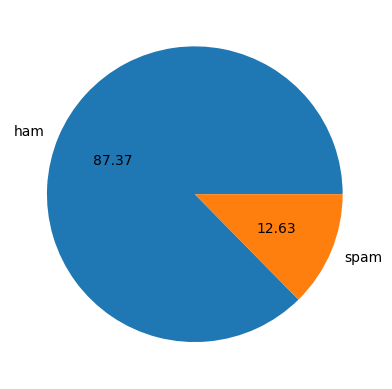

In [111]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct='%0.2f')
plt.show()

In [154]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords',quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


True

In [155]:
df['chars'] = df['text'].apply(len)

In [114]:
df.head()

,target,text,chars
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [156]:
df['num_word'] = df['text'].astype(str).apply(lambda x: len(nltk.word_tokenize(x, preserve_line=True)))

In [116]:
df.head()

,target,text,chars,num_word
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [157]:
df['num_sent'] = df['text'].astype(str).apply(lambda x: len(nltk.sent_tokenize(x)))

In [118]:
df.head()

,target,text,chars,num_word,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [158]:
df.rename(columns={'chars':'num_chars'},inplace=True)

In [120]:
df[['num_chars','num_word','num_sent']].describe()

,num_chars,num_word,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,17.864964,1.965564
std,58.236293,12.776749,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,14.000000,1.000000
75%,117.000000,25.000000,2.000000
max,910.000000,215.000000,38.000000


In [121]:
df[df['target'] == 0][['num_chars','num_word','num_sent']].describe()

,num_chars,num_word,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,16.618468,1.820195
std,56.358207,12.962931,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,21.000000,2.000000
max,910.000000,215.000000,38.000000


In [122]:
df[df['target'] == 1][['num_chars','num_word','num_sent']].describe()


,num_chars,num_word,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,26.485452,2.970904
std,30.137753,6.717242,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,24.000000,2.000000
50%,149.000000,28.000000,3.000000
75%,157.000000,31.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_chars', ylabel='Count'>

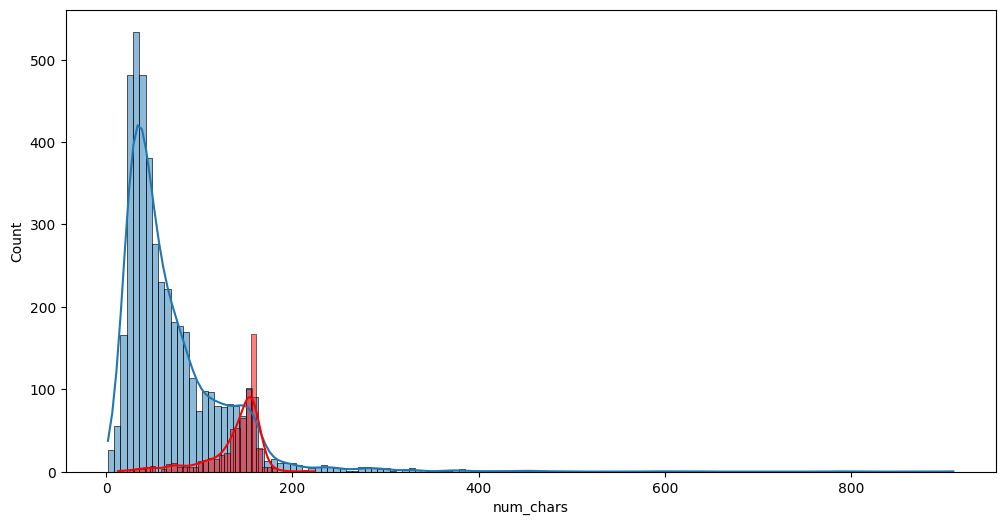

In [123]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_chars'],kde=True)
sns.histplot(df[df['target'] == 1]['num_chars'],kde=True,color='red')


<Axes: xlabel='num_word', ylabel='Count'>

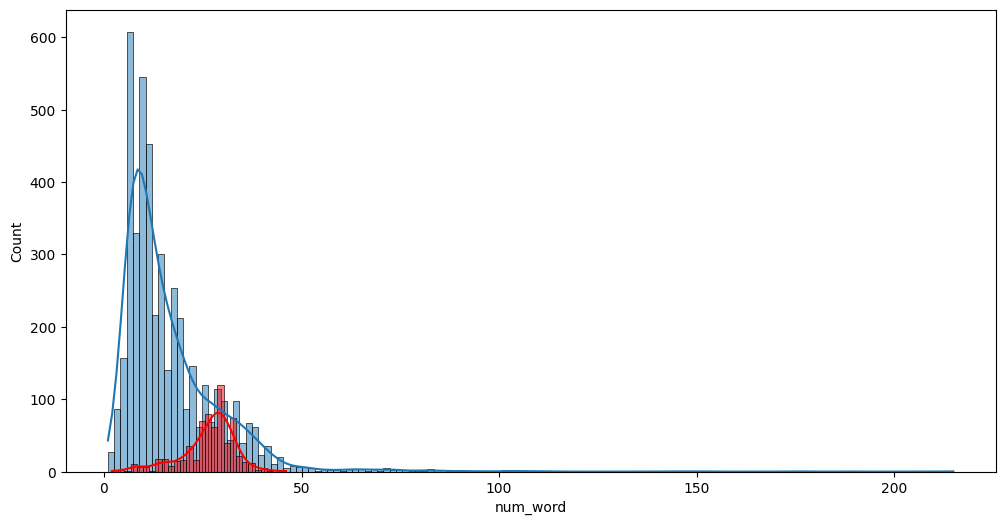

In [124]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_word'],kde=True)
sns.histplot(df[df['target'] == 1]['num_word'],kde=True,color='red')

<Axes: xlabel='num_sent', ylabel='Count'>

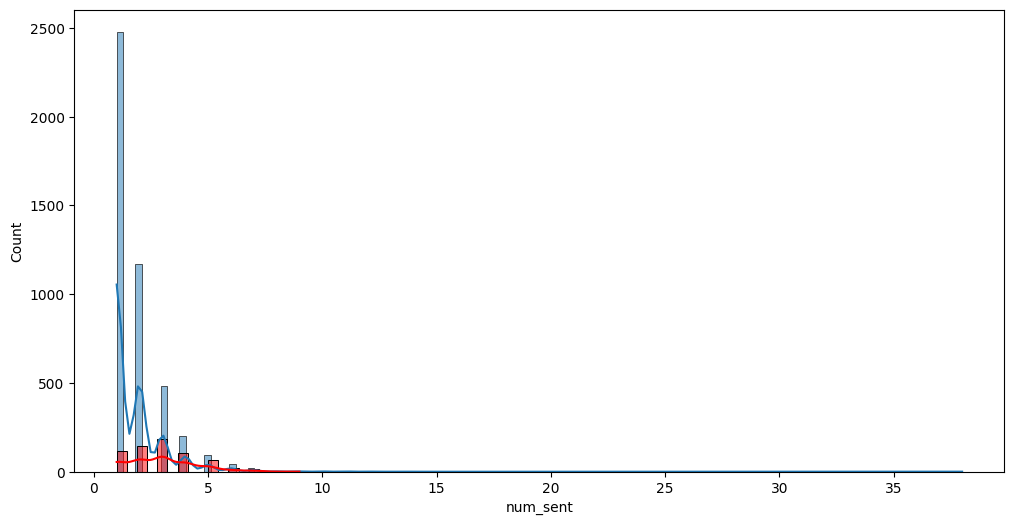

In [125]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_sent'],kde=True)
sns.histplot(df[df['target'] == 1]['num_sent'],kde=True,color='red')

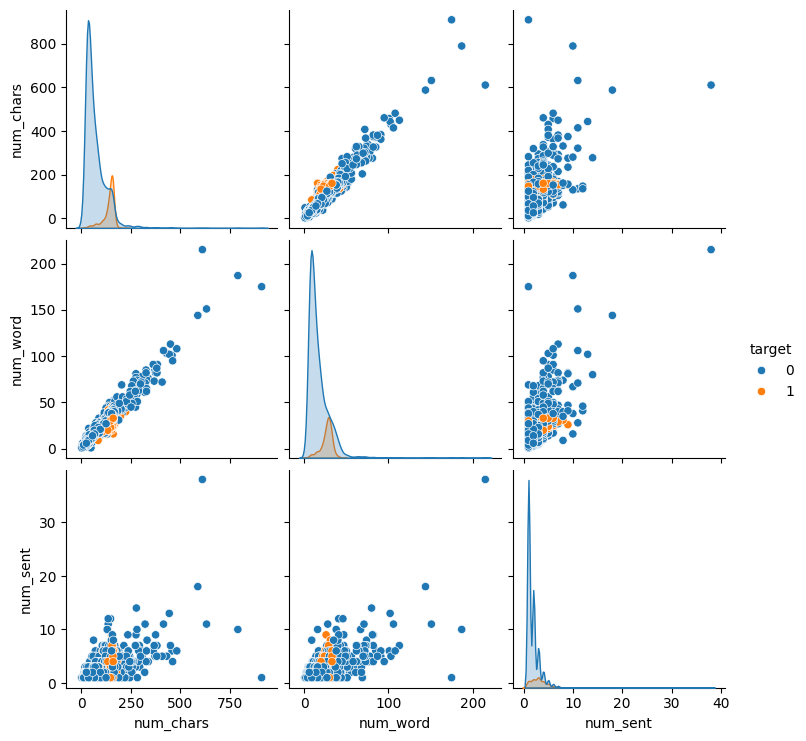

In [126]:
sns.pairplot(df,hue='target')

<Axes: >

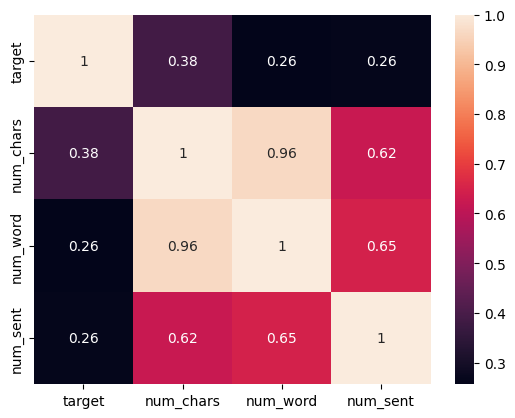

In [127]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Data Preprocessing
1. lower case
2. tokenization
3. removing special charachters,stop words and punctuations
4. stemming 

In [159]:
import string
from nltk.stem import PorterStemmer

ps = PorterStemmer()




def text_transform(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [129]:
text_transform(df['text'][106])

'aight hit get cash aight hit get cash'

In [160]:
df['transformed_text'] = df['text'].apply(text_transform)

In [131]:
df.head()

,target,text,num_chars,num_word,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say u dun say ...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goes usf lives around though nah thi...


In [132]:
df.columns

Index(['target', 'text', 'num_chars', 'num_word', 'num_sent',
       'transformed_text'],
      dtype='str')

In [133]:
from wordcloud import WordCloud


In [134]:
wc = WordCloud(height=500,width=500,min_font_size=10,background_color='black')

In [135]:
spamed_wc  = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=' '))

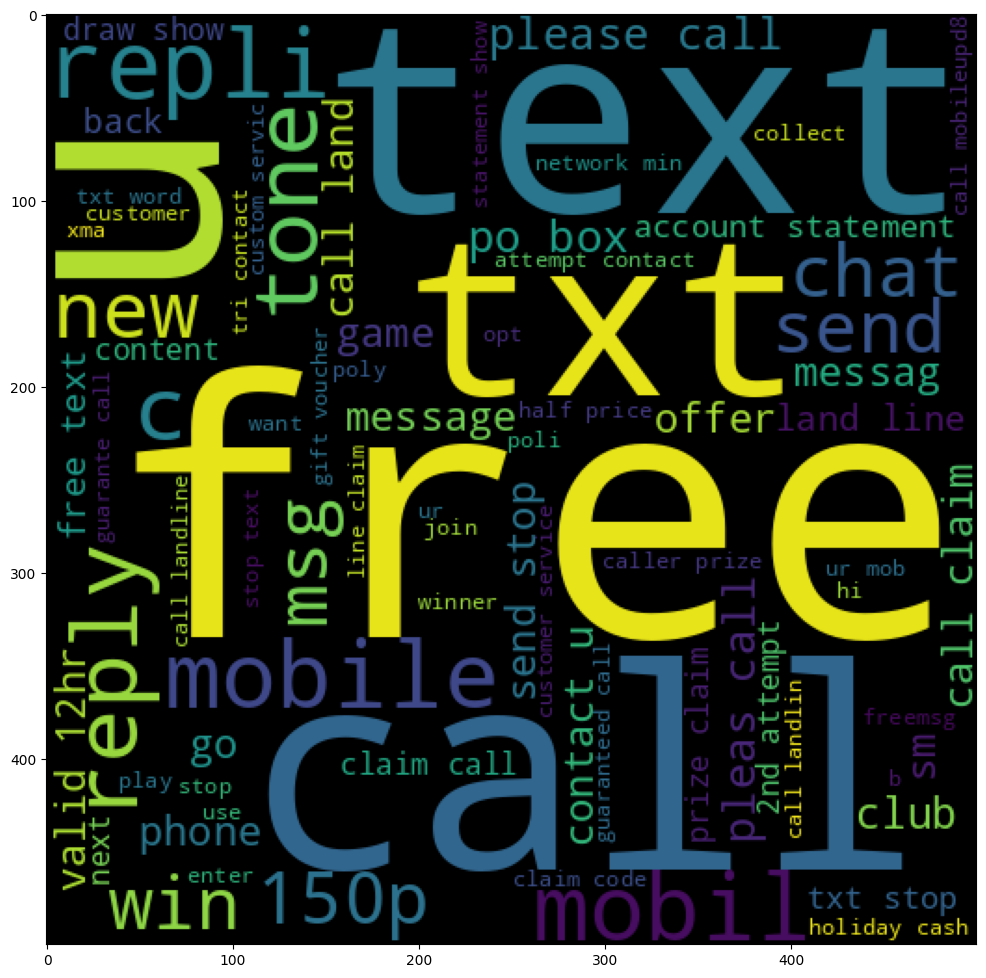

In [136]:
plt.figure(figsize=(12,15))
plt.imshow(spamed_wc)

In [137]:
hamed_wc  = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=' '))


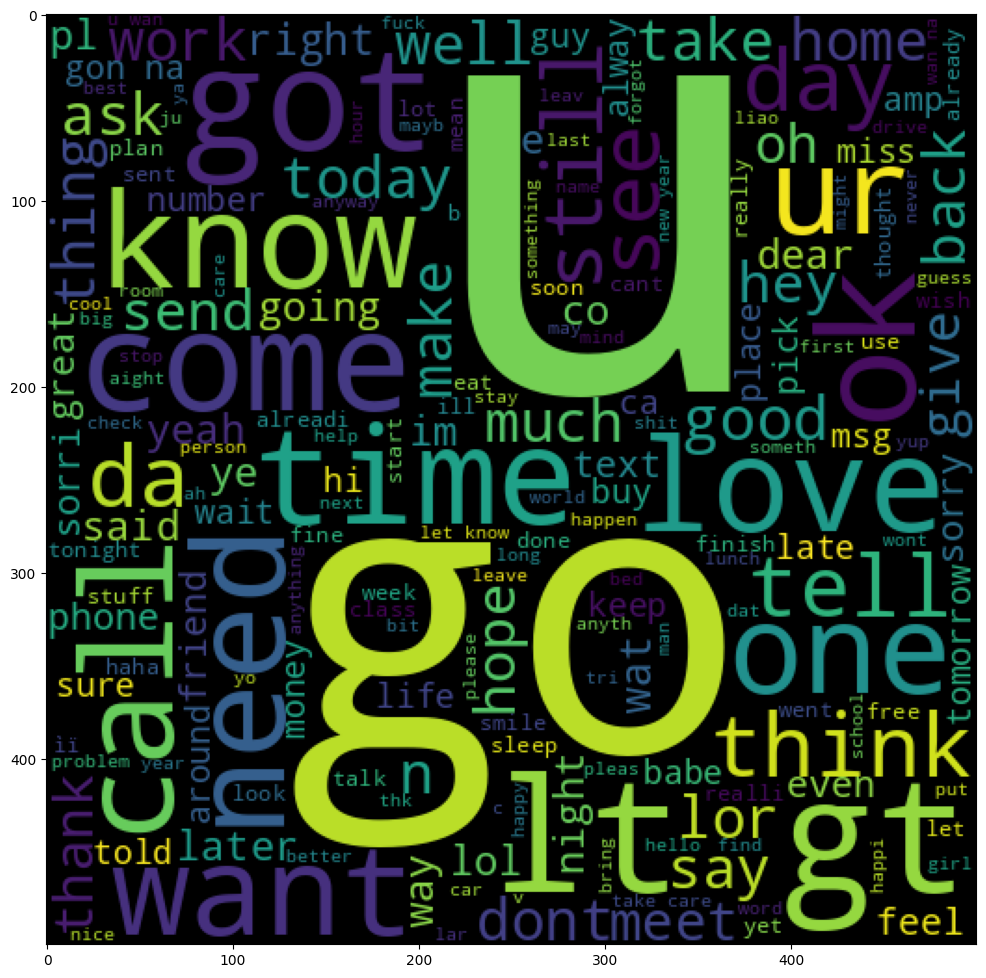

In [138]:
plt.figure(figsize=(12,15))
plt.imshow(hamed_wc)

In [139]:
df.head()

,target,text,num_chars,num_word,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say u dun say ...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goes usf lives around though nah thi...


In [140]:
df[df['target'] == 1]['transformed_text'].to_list()

['free entry 2 wkly comp win fa cup final tkts 21st may text fa 87121 receive entry question std txt rate c apply 08452810075over18 free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18',
 'freemsg hey darling 3 week word back like fun still tb ok xxx std chgs send rcv freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv',
 'winner valued network customer selected receivea prize reward claim call claim code kl341 valid 12 hours winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour',
 'mobile 11 months u r entitled update latest colour mobiles camera free call mobile update co free 08002986030 mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030',
 'six chances win cash 100 pounds txt csh11 send cost 6days tsandcs apply reply hl 4 info six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli

In [161]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].to_list():
    for word in msg.split():
        spam_corpus.append(word)
        


In [142]:
len(spam_corpus)

19878

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'call'),
  Text(1, 0, 'free'),
  Text(2, 0, '2'),
  Text(3, 0, 'txt'),
  Text(4, 0, 'u'),
  Text(5, 0, 'ur'),
  Text(6, 0, 'text'),
  Text(7, 0, 'stop'),
  Text(8, 0, 'claim'),
  Text(9, 0, '4'),
  Text(10, 0, 'prize'),
  Text(11, 0, 'get'),
  Text(12, 0, 'new'),
  Text(13, 0, 'send'),
  Text(14, 0, 'mobil'),
  Text(15, 0, 'urgent'),
  Text(16, 0, 'nokia'),
  Text(17, 0, 'contact'),
  Text(18, 0, 'mobile'),
  Text(19, 0, 'repli'),
  Text(20, 0, 'cash'),
  Text(21, 0, 'tone'),
  Text(22, 0, 'reply'),
  Text(23, 0, 'win'),
  Text(24, 0, 'phone'),
  Text(25, 0, 'c'),
  Text(26, 0, 'week'),
  Text(27, 0, 'per'),
  Text(28, 0, 'award'),
  Text(29, 0, 'chat')])

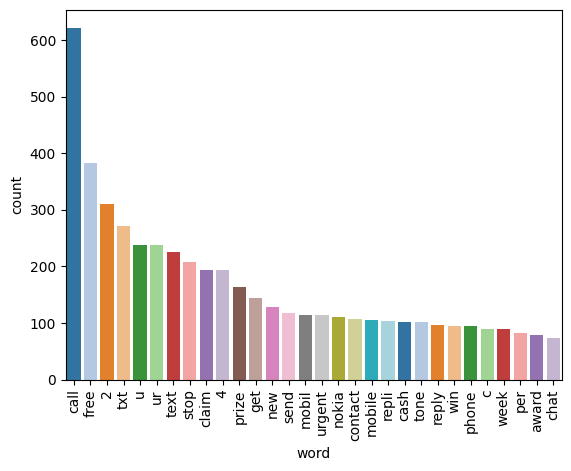

In [162]:
from collections import Counter

spam_top_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(x='word', y='count', data=spam_top_df, palette='tab20')
plt.xticks(rotation='vertical')

In [163]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].to_list():
    for word in msg.split():
        ham_corpus.append(word)
        

In [164]:
len(ham_corpus)

70808

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'u'),
  Text(1, 0, 'go'),
  Text(2, 0, 'get'),
  Text(3, 0, 'gt'),
  Text(4, 0, 'lt'),
  Text(5, 0, '2'),
  Text(6, 0, 'come'),
  Text(7, 0, 'got'),
  Text(8, 0, 'know'),
  Text(9, 0, 'like'),
  Text(10, 0, 'ok'),
  Text(11, 0, 'good'),
  Text(12, 0, 'call'),
  Text(13, 0, 'time'),
  Text(14, 0, 'ur'),
  Text(15, 0, 'love'),
  Text(16, 0, 'want'),
  Text(17, 0, 'day'),
  Text(18, 0, 'one'),
  Text(19, 0, 'need'),
  Text(20, 0, 'lor'),
  Text(21, 0, '4'),
  Text(22, 0, 'home'),
  Text(23, 0, 'still'),
  Text(24, 0, 'da'),
  Text(25, 0, 'see'),
  Text(26, 0, 'think'),
  Text(27, 0, 'take'),
  Text(28, 0, 'back'),
  Text(29, 0, 'tell')])

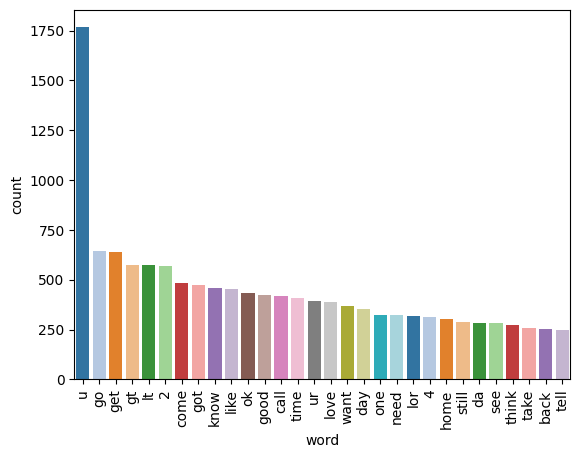

In [165]:
from collections import Counter

ham_top_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(x='word', y='count', data=ham_top_df, palette='tab20')
plt.xticks(rotation='vertical')